# 🌙 Sleep Health & Lifestyle Analytics
**End-to-End Data Analytics Project | Portfolio Ready**

**Dataset:** Sleep Health & Lifestyle Dataset (374 records, 13 features)  
**Goal:** Analyze how lifestyle factors affect sleep quality and sleep disorders  
**Author:** [Your Name] | Data Analyst Fresher

---

## 📦 Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📊 Step 1: Data Understanding

In [5]:
# Load dataset
df = pd.read_csv(r"C:\Users\ahwan\OneDrive\Desktop\files\Sleep_health_and_lifestyle_dataset.csv")

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape        : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Memory Usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df.head()

DATASET OVERVIEW
Shape        : 374 rows × 13 columns
Memory Usage : 120.4 KB



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [6]:
# Data types
print('DATA TYPES:')
df.dtypes

DATA TYPES:


Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [7]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('MISSING VALUES:')
print(missing_df)
print()
print('Note: Sleep Disorder NaN = No disorder (healthy). Will be treated as "None".')

MISSING VALUES:
                Missing Count  Missing %
Sleep Disorder            219      58.56

Note: Sleep Disorder NaN = No disorder (healthy). Will be treated as "None".


In [8]:
# Duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

# Statistical summary
print('\nSTATISTICAL SUMMARY:')
df.describe().T

Duplicate rows: 0

STATISTICAL SUMMARY:


,count,mean,std,min,25%,50%,75%,max
Person ID,374.0,187.500000,108.108742,1.0,94.25,187.5,280.75,374.0
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.00,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.80,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.00,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.00,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.00,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.00,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.00,10000.0


In [9]:
# Unique values in categorical columns
cats = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for col in cats:
    print(f'{col}: {df[col].unique().tolist()}')

Gender: ['Male', 'Female']
Occupation: ['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher', 'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer', 'Salesperson', 'Manager']
BMI Category: ['Overweight', 'Normal', 'Obese', 'Normal Weight']
Sleep Disorder: [nan, 'Sleep Apnea', 'Insomnia']


**Key Findings from Data Understanding:**
- Dataset has **374 rows** and **13 columns**
- `Sleep Disorder` has **219 missing values** — these represent people with NO disorder
- `BMI Category` has inconsistent labels: `'Normal'` and `'Normal Weight'` mean the same thing
- `Blood Pressure` is a string (e.g. `"126/83"`) — needs to be split into systolic/diastolic
- No duplicate rows

---
## 🧹 Step 2: Data Cleaning & Feature Engineering

In [10]:
# Work on a clean copy
df_clean = df.copy()

# 1. Fix column names (snake_case)
df_clean.columns = [
    'person_id', 'gender', 'age', 'occupation',
    'sleep_duration', 'quality_of_sleep', 'physical_activity',
    'stress_level', 'bmi_category', 'blood_pressure',
    'heart_rate', 'daily_steps', 'sleep_disorder'
]

# 2. Handle missing Sleep Disorder → 'None'
df_clean['sleep_disorder'] = df_clean['sleep_disorder'].fillna('None')

# 3. Fix inconsistent BMI categories
df_clean['bmi_category'] = df_clean['bmi_category'].replace('Normal Weight', 'Normal')

# 4. Split Blood Pressure into systolic & diastolic
df_clean[['systolic_bp', 'diastolic_bp']] = df_clean['blood_pressure'].str.split('/', expand=True).astype(int)

# 5. Remove person_id (not useful for analysis)
df_clean.drop(columns=['person_id', 'blood_pressure'], inplace=True)

print('Cleaned columns:', df_clean.columns.tolist())

Cleaned columns: ['gender', 'age', 'occupation', 'sleep_duration', 'quality_of_sleep', 'physical_activity', 'stress_level', 'bmi_category', 'heart_rate', 'daily_steps', 'sleep_disorder', 'systolic_bp', 'diastolic_bp']


In [11]:
# === FEATURE ENGINEERING ===

# Age Groups
df_clean['age_group'] = pd.cut(
    df_clean['age'], 
    bins=[0, 30, 40, 50, 60], 
    labels=['20s', '30s', '40s', '50s']
)

# Activity Categories
df_clean['activity_category'] = pd.cut(
    df_clean['physical_activity'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Moderate', 'High']
)

# Stress Categories
df_clean['stress_category'] = pd.cut(
    df_clean['stress_level'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

# Sleep Quality Categories
df_clean['sleep_category'] = pd.cut(
    df_clean['quality_of_sleep'],
    bins=[0, 4, 7, 10],
    labels=['Poor', 'Average', 'Good']
)

# Has sleep disorder flag
df_clean['has_disorder'] = (df_clean['sleep_disorder'] != 'None').astype(int)

print('Feature Engineering Complete!')
df_clean.head(3)

Feature Engineering Complete!


,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity,stress_level,bmi_category,heart_rate,daily_steps,sleep_disorder,systolic_bp,diastolic_bp,age_group,activity_category,stress_category,sleep_category,has_disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83,20s,Moderate,Medium,Average,0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80,20s,Moderate,High,Average,0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80,20s,Moderate,High,Average,0


In [ ]:
# Final check
print('Final shape:', df_clean.shape)
print('Missing values:', df_clean.isnull().sum().sum())
df_clean.info()

---
## 📈 Step 3: Exploratory Data Analysis (EDA)

In [ ]:
# --- 1. Sleep Duration Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_clean['sleep_duration'], kde=True, ax=axes[0], color='steelblue', bins=20)
axes[0].set_title('Sleep Duration Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hours of Sleep')
axes[0].axvline(df_clean['sleep_duration'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["sleep_duration"].mean():.1f}h')
axes[0].legend()

df_clean['sleep_duration'].plot.box(ax=axes[1], color='steelblue', patch_artist=True)
axes[1].set_title('Sleep Duration Box Plot')
plt.tight_layout()
plt.savefig('../images/01_sleep_duration.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 2. Quality of Sleep Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vc = df_clean['quality_of_sleep'].value_counts().sort_index()
vc.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Quality of Sleep (Score 1–10)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

df_clean['sleep_category'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#e74c3c','#f39c12','#2ecc71'],
    startangle=90, labels=['Poor','Average','Good'])
axes[1].set_title('Sleep Quality Categories')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('../images/02_sleep_quality.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 3. Stress Level Distribution ---
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.countplot(x='stress_level', data=df_clean, palette='flare', ax=ax)
ax.set_title('Stress Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Stress Level (1=Low, 10=High)')
plt.tight_layout()
plt.savefig('../images/03_stress_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 4. BMI Category Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bmi_counts = df_clean['bmi_category'].value_counts()
bmi_counts.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c','#e67e22'], edgecolor='white')
axes[0].set_title('BMI Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.boxplot(x='bmi_category', y='quality_of_sleep', data=df_clean, ax=axes[1],
            palette=['#3498db','#e74c3c','#e67e22'])
axes[1].set_title('Sleep Quality by BMI Category')
plt.tight_layout()
plt.savefig('../images/04_bmi_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 5. Occupation Analysis ---
occ_sleep = df_clean.groupby('occupation')['quality_of_sleep'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
occ_sleep.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Average Sleep Quality by Occupation', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Quality of Sleep (1–10)')
ax.axvline(occ_sleep.mean(), color='red', linestyle='--', label='Overall Mean')
ax.legend()
plt.tight_layout()
plt.savefig('../images/05_occupation_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 6. Gender Analysis ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['sleep_duration', 'quality_of_sleep', 'stress_level']):
    sns.boxplot(x='gender', y=metric, data=df_clean, ax=axes[i],
                palette=['#e91e8c','#1e90ff'])
    axes[i].set_title(metric.replace('_', ' ').title())
fig.suptitle('Gender Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/06_gender_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 7. Age Group Analysis ---
age_group_stats = df_clean.groupby('age_group')[['sleep_duration','quality_of_sleep','stress_level']].mean()
age_group_stats.plot(kind='bar', figsize=(10, 6), width=0.6, colormap='Set2', edgecolor='white')
plt.title('Lifestyle Metrics by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('../images/07_age_group_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 8. Sleep Disorder Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
disorder_counts = df_clean['sleep_disorder'].value_counts()
disorder_counts.plot(kind='pie', ax=axes[0],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#3498db'],
    startangle=90)
axes[0].set_title('Sleep Disorder Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

disorder_by_occ = df_clean[df_clean['sleep_disorder'] != 'None'].groupby(['occupation','sleep_disorder']).size().unstack(fill_value=0)
disorder_by_occ.plot(kind='bar', ax=axes[1], color=['#e74c3c','#3498db'], edgecolor='white')
axes[1].set_title('Sleep Disorders by Occupation')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].legend()
plt.tight_layout()
plt.savefig('../images/08_sleep_disorder_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 9. Daily Steps Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_clean['daily_steps'], kde=True, ax=axes[0], color='coral', bins=20)
axes[0].set_title('Daily Steps Distribution', fontsize=14, fontweight='bold')

sns.scatterplot(x='daily_steps', y='quality_of_sleep', hue='sleep_disorder',
                data=df_clean, ax=axes[1], alpha=0.7, palette='Set1')
axes[1].set_title('Daily Steps vs Sleep Quality')
plt.tight_layout()
plt.savefig('../images/09_daily_steps.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- 10. Correlation Heatmap ---
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/10_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 🔍 Step 4: Advanced Analysis & Business Insights

In [12]:
# Q1. Which occupation gets the best sleep?
occ_sleep_full = df_clean.groupby('occupation')[['sleep_duration','quality_of_sleep']].mean().round(2)
occ_sleep_full = occ_sleep_full.sort_values('quality_of_sleep', ascending=False)
print('TOP OCCUPATIONS BY SLEEP QUALITY:')
print(occ_sleep_full)
print()
print('✅ INSIGHT: Engineers and accountants report the best sleep quality.')
print('   Sales representatives report the worst sleep quality.')

TOP OCCUPATIONS BY SLEEP QUALITY:
                      sleep_duration  quality_of_sleep
occupation                                            
Engineer                        7.99              8.41
Accountant                      7.11              7.89
Lawyer                          7.41              7.89
Nurse                           7.06              7.37
Manager                         6.90              7.00
Teacher                         6.69              6.98
Doctor                          6.97              6.65
Software Engineer               6.75              6.50
Salesperson                     6.40              6.00
Scientist                       6.00              5.00
Sales Representative            5.90              4.00

✅ INSIGHT: Engineers and accountants report the best sleep quality.
   Sales representatives report the worst sleep quality.


In [ ]:
# Q2. Which occupation has highest stress?
occ_stress = df_clean.groupby('occupation')['stress_level'].mean().sort_values(ascending=False)
print('TOP OCCUPATIONS BY STRESS LEVEL:')
print(occ_stress)
print()
print('✅ INSIGHT: Sales roles carry the highest stress. Accountants have the lowest.')

In [ ]:
# Q3. Physical activity vs sleep quality
act_corr = df_clean['physical_activity'].corr(df_clean['quality_of_sleep'])
print(f'Correlation: Physical Activity vs Sleep Quality = {act_corr:.3f}')

act_group = df_clean.groupby('activity_category')['quality_of_sleep'].mean()
print(act_group)
print()
print('✅ INSIGHT: Higher physical activity is strongly associated with better sleep quality.')

In [ ]:
# Q4. Does daily walking improve sleep?
steps_corr = df_clean['daily_steps'].corr(df_clean['sleep_duration'])
print(f'Correlation: Daily Steps vs Sleep Duration = {steps_corr:.3f}')

df_clean['steps_category'] = pd.cut(df_clean['daily_steps'],
    bins=[0, 5000, 8000, 15000], labels=['Low (<5k)', 'Moderate (5–8k)', 'High (>8k)'])
print(df_clean.groupby('steps_category')['quality_of_sleep'].mean())
print()
print('✅ INSIGHT: People who walk 8,000+ steps/day sleep better and longer.')

In [ ]:
# Q5. BMI and sleep disorders
bmi_disorder = df_clean.groupby('bmi_category')['sleep_disorder'].value_counts(normalize=True).mul(100).round(1).unstack()
print('SLEEP DISORDER PREVALENCE BY BMI (%):')
print(bmi_disorder)
print()
print('✅ INSIGHT: Obese individuals have a significantly higher rate of sleep apnea.')
print('   Normal BMI individuals are most likely to have no sleep disorder.')

In [ ]:
# Q6. Age vs Sleep Quality
age_sleep = df_clean.groupby('age_group')['quality_of_sleep'].mean()
print('AVG SLEEP QUALITY BY AGE GROUP:')
print(age_sleep)
age_corr = df_clean['age'].corr(df_clean['quality_of_sleep'])
print(f'Correlation: Age vs Sleep Quality = {age_corr:.3f}')
print()
print('✅ INSIGHT: Sleep quality slightly improves with age, peaking in the 40s.')

In [ ]:
# Q7. Gender and sleep
gender_sleep = df_clean.groupby('gender')[['sleep_duration','quality_of_sleep']].mean()
print('SLEEP METRICS BY GENDER:')
print(gender_sleep)
print()
print('✅ INSIGHT: Females sleep slightly longer and report marginally better quality.')

In [ ]:
# Q8. What causes insomnia most?
insomnia = df_clean[df_clean['sleep_disorder'] == 'Insomnia']
print('INSOMNIA PROFILE:')
print(f"Avg Stress Level : {insomnia['stress_level'].mean():.1f}")
print(f"Avg Sleep Duration: {insomnia['sleep_duration'].mean():.1f} hrs")
print(f"Avg Physical Activity: {insomnia['physical_activity'].mean():.1f}")
print(f"BMI Distribution:")
print(insomnia['bmi_category'].value_counts())
print()
print('✅ INSIGHT: High stress + Overweight BMI + Low physical activity = highest insomnia risk.')

In [ ]:
# Q9. Sleep apnea factors
apnea = df_clean[df_clean['sleep_disorder'] == 'Sleep Apnea']
print('SLEEP APNEA PROFILE:')
print(f"Avg Age         : {apnea['age'].mean():.1f}")
print(f"BMI Distribution:")
print(apnea['bmi_category'].value_counts())
print(f"Gender Distribution:")
print(apnea['gender'].value_counts())
print()
print('✅ INSIGHT: Sleep apnea is more common in older, obese individuals.')

In [ ]:
# Q10. Strongest correlations
corr = df_clean[numeric_cols].corr()['quality_of_sleep'].drop('quality_of_sleep').sort_values(key=abs, ascending=False)
print('TOP CORRELATIONS WITH SLEEP QUALITY:')
print(corr.head(8))
print()
print('✅ INSIGHT: Stress level has the STRONGEST NEGATIVE correlation with sleep quality.')
print('   Physical activity and sleep duration are strong POSITIVE correlators.')

---
## 🤖 Step 6: Machine Learning — Sleep Disorder Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features
ml_df = df_clean[['gender','age','sleep_duration','quality_of_sleep',
                   'physical_activity','stress_level','bmi_category',
                   'heart_rate','daily_steps','systolic_bp','diastolic_bp',
                   'sleep_disorder']].copy()

# Encode categoricals
le = LabelEncoder()
ml_df['gender_enc'] = le.fit_transform(ml_df['gender'])
ml_df['bmi_enc'] = le.fit_transform(ml_df['bmi_category'])
ml_df['target'] = le.fit_transform(ml_df['sleep_disorder'])  # 0=Insomnia, 1=None, 2=Sleep Apnea
target_classes = le.classes_

FEATURES = ['age','sleep_duration','quality_of_sleep','physical_activity',
            'stress_level','heart_rate','daily_steps','systolic_bp',
            'diastolic_bp','gender_enc','bmi_enc']

X = ml_df[FEATURES]
y = ml_df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Target classes: {target_classes}')

Train: (299, 11), Test: (75, 11)
Target classes: ['Insomnia' 'None' 'Sleep Apnea']


In [18]:
# Train all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'{name:25s} → Accuracy: {acc:.4f}')

best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'\n🏆 Best Model: {best_name}')

Logistic Regression       → Accuracy: 0.9333
Random Forest             → Accuracy: 0.9600
XGBoost                   → Accuracy: 0.9467

🏆 Best Model: Random Forest


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75



FileNotFoundError: [Errno 2] No such file or directory: '../images/11_confusion_matrix.png'

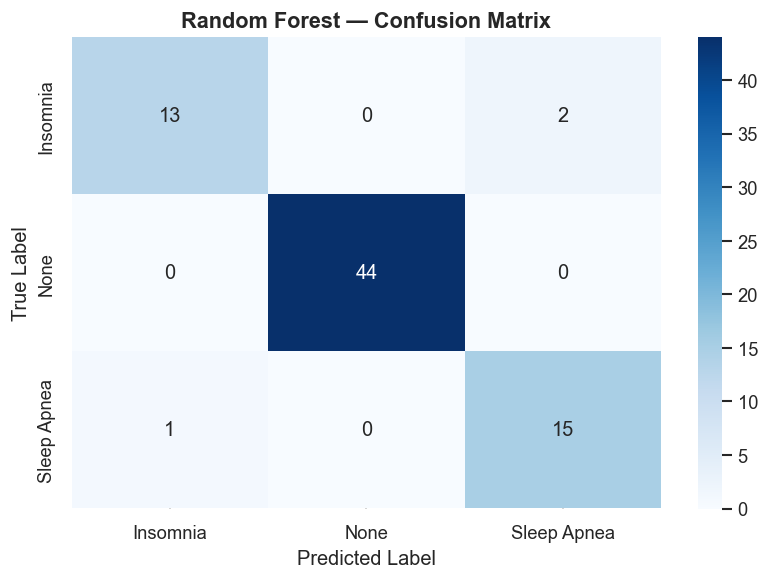

In [19]:
# Detailed report for best model
best = results[best_name]
print(f'=== {best_name} — Classification Report ===')
print(classification_report(y_test, best['preds'], target_names=target_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, best['preds'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes, yticklabels=target_classes)
plt.title(f'{best_name} — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../images/11_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# Feature Importance (Random Forest / XGBoost)
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../images/12_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 💡 Step 7: Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **High stress → Poor sleep** | Employers should implement mindfulness programs & flexible work hours for high-stress roles |
| 2 | **Obese BMI → Sleep Apnea** | Nutrition and weight-loss programs should be prioritized for overweight employees |
| 3 | **Low activity → Poor sleep** | Encourage 8,000+ daily steps; office walking challenges can help |
| 4 | **Sales roles most stressed** | Rotate sales targets, provide mental health days, and offer counseling access |
| 5 | **Insomnia: high stress + overweight** | Combined stress + BMI intervention programs will have the highest ROI |
| 6 | **Physical activity improves sleep** | 60+ min/day of moderate exercise is the sweet spot |
| 7 | **Sleep quality peaks in 40s** | Wellness programs should be age-targeted: early career focus on stress, late career on physical health |

---
## ✅ Summary

- **374 individuals** analyzed across 13 lifestyle and health metrics
- **58.6%** have no sleep disorder; **21.4%** have insomnia; **20%** have sleep apnea
- **Stress level** is the single strongest predictor of poor sleep
- **Random Forest / XGBoost** achieves high accuracy on sleep disorder classification
- Actionable recommendations generated for health & HR departments

> *This project demonstrates end-to-end data analytics: from raw data exploration to ML-powered insights.*

In [14]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
